# GoodAir — Modèles Machine Learning

Ce notebook implémente trois modèles complémentaires pour GoodAir :

| Modèle | Target | Données | Usage métier |
|--------|--------|---------|-------------|
| **Modèle 1** | AQI J+1 et J+2 | Journalières 2013–2025 (~71k lignes) | Anticiper les pics de pollution |
| **Modèle 2** | AQI temps réel | Horaires déc. 2025 (~13k lignes) | Estimer l'AQI des villes sans capteur |
| **Modèle 3** | Température +12h et +24h | Horaires déc. 2025 (~23k lignes) | Prévoir la température à court terme |


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from dotenv import load_dotenv
import snowflake.connector

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Imports OK')


/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/snowflake/connector/options.py:128: UserWarning: You have an incompatible version of 'pyarrow' installed (11.0.0), please install a version that adheres to: 'pyarrow>=14.0.1; extra == "pandas"'
  warn_incompatible_dep(


Imports OK


## 2. Connexion Snowflake

In [2]:
load_dotenv()
conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='GOLD',
)
print('Connexion Snowflake OK')


Connexion Snowflake OK


## 3. Chargement des données

In [3]:
query = """
SELECT f.*, d.latitude, d.longitude
FROM GOLD.FUSION_AQICN_WEATHER f
LEFT JOIN SILVER.DIM_CITY d
    ON f.city_id = d.city_id
"""

df_all = pd.read_sql(query, conn)
df_all.columns = [c.lower() for c in df_all.columns]
df_all['dt_hour'] = pd.to_datetime(df_all['dt_hour'], errors='coerce', utc=True)
df_all = df_all[df_all['dt_hour'].notna()].copy()

print(f'Shape total  : {df_all.shape}')
print(f'Periode      : {df_all["dt_hour"].min()} -> {df_all["dt_hour"].max()}')
print(f'Villes       : {df_all["city_id"].nunique()}')


/var/folders/tv/lm4xf58100z0w350rlffy8fr0000gn/T/ipykernel_11519/1423570205.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_all = pd.read_sql(query, conn)


Shape total  : (63121, 46)
Periode      : 2020-01-01 00:00:00+00:00 -> 2026-03-06 23:00:00+00:00
Villes       : 21


## 4. Séparation données journalières / horaires

- **Avant le 12/12/2025** : données journalières AQICN (2013–2025) → Modèles 1
- **À partir du 12/12/2025** : données horaires AQICN + OpenWeather → Modèles 2 et 3

In [4]:
CUTOFF = pd.Timestamp('2025-12-12', tz='UTC')

df_daily  = df_all[df_all['dt_hour'] <  CUTOFF].copy()
df_hourly = df_all[df_all['dt_hour'] >= CUTOFF].copy()

print(f'Journalier : {len(df_daily):,} lignes | {df_daily["dt_hour"].min().date()} -> {df_daily["dt_hour"].max().date()}')
print(f'Horaire    : {len(df_hourly):,} lignes | {df_hourly["dt_hour"].min().date()} -> {df_hourly["dt_hour"].max().date()}')


Journalier : 37,442 lignes | 2020-01-01 -> 2025-12-11
Horaire    : 25,679 lignes | 2025-12-12 -> 2026-03-06


## 5. Fonctions utilitaires

In [5]:
LINEAR_MODELS = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
}
TREE_MODELS = {
    'DecisionTree':     DecisionTreeRegressor(random_state=42),
    'RandomForest':     RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
}

def build_pipeline(model, features, is_linear=True):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if is_linear:
        steps.append(('scaler', StandardScaler()))
    preprocess = ColumnTransformer([
        ('num', Pipeline(steps), features)
    ], remainder='drop')
    return Pipeline([('preprocess', preprocess), ('model', clone(model))])

def split_by_city(df, date_col, test_size=0.2):
    train_dfs, test_dfs = [], []
    for city, group in df.groupby('city_id'):
        group = group.sort_values(date_col).reset_index(drop=True)
        n = len(group)
        cutoff = int(n * (1 - test_size))
        train_dfs.append(group.iloc[:cutoff])
        test_dfs.append(group.iloc[cutoff:])
    return pd.concat(train_dfs).reset_index(drop=True), pd.concat(test_dfs).reset_index(drop=True)

def train_and_evaluate(train_df, test_df, features, target):
    results = {}
    best_r2, best_model = -np.inf, None

    print(f'\n{"="*52}')
    print(f'  TARGET : {target}')
    print(f'{"="*52}')

    for name, model in {**LINEAR_MODELS, **TREE_MODELS}.items():
        pipe = build_pipeline(model, features, is_linear=(name in LINEAR_MODELS))
        pipe.fit(train_df[features], train_df[target])
        pred = pipe.predict(test_df[features])

        r2   = r2_score(test_df[target], pred)
        mae  = mean_absolute_error(test_df[target], pred)
        rmse = np.sqrt(mean_squared_error(test_df[target], pred))

        results[name] = {'r2': r2, 'mae': mae, 'rmse': rmse, 'model': pipe}
        flag = 'OK' if r2 >= 0.5 else '!!'
        print(f'  [{flag}] {name:<22}  R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}')

        if r2 > best_r2:
            best_r2, best_model = r2, pipe

    print(f'  => Meilleur modele : R2 = {best_r2:.3f}')
    return results, best_model

print('Fonctions utilitaires OK')


Fonctions utilitaires OK


---
# MODÈLE 1 — Prédiction AQI futur (J+1 et J+2)
*Données journalières AQICN | 2013–2025 | ~71 000 lignes | 21 villes*

**Cas d'usage :** anticiper les pics de pollution pour alerter la population et les chercheurs à l'avance.

## 6. Préparation données journalières

In [6]:
df = df_daily.copy()

# Deduplication : une valeur par ville+jour
df['date'] = df['dt_hour'].dt.date
df = df.groupby(['city_id', 'date'], as_index=False).mean(numeric_only=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city_id', 'date']).reset_index(drop=True)

# Features calendaires
df['month']       = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_year'] = df['date'].dt.dayofyear
df['year']        = df['date'].dt.year

# Nettoyage
df = df.replace(-999, np.nan)
df = df.groupby('city_id', group_keys=False).apply(lambda g: g.interpolate(method='linear'))
df = df.reset_index(drop=True)
cols_force = ['aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48']
df = df.loc[:, (df.isna().mean() < 0.7) | (df.columns.isin(cols_force))]
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(f'Shape : {df.shape}')
print(f'Doublons : {df.duplicated(["city_id","date"]).sum()}')
print(f'Missing  : {df.isna().sum().sum()}')


Shape : (37427, 24)
Doublons : 0
Missing  : 37427


## 7. Création des targets AQI futur

In [7]:
df = df.sort_values(['city_id', 'date']).reset_index(drop=True)

df['aqi_j1'] = df.groupby('city_id')['aqi'].shift(-1)
df['aqi_j2'] = df.groupby('city_id')['aqi'].shift(-2)

# Verification
city_test = df['city_id'].iloc[0]
s = df[df['city_id'] == city_test].sort_values('date').reset_index(drop=True)
print('Verification aqi_j1 :')
print(f'  aqi[0]    = {s.loc[0,"aqi"]:.1f}  ({s.loc[0,"date"].date()})')
print(f'  aqi[1]    = {s.loc[1,"aqi"]:.1f}  ({s.loc[1,"date"].date()})')
print(f'  aqi_j1[0] = {s.loc[0,"aqi_j1"]:.1f}  <- doit etre egal a aqi[1]')

df = df.dropna(subset=['aqi_j1', 'aqi_j2'])
print(f'\nShape final : {df.shape}')


Verification aqi_j1 :
  aqi[0]    = 25.0  (2020-01-01)
  aqi[1]    = 23.0  (2020-01-02)
  aqi_j1[0] = 23.0  <- doit etre egal a aqi[1]

Shape final : (37386, 26)


## 8. Features Modèle 1

In [8]:
FEATURES_M1 = [
    'aqi', 'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48',
    'iaqi_pm10', 'pm10_lag_12', 'pm10_lag_24',
    'iaqi_pm25', 'pm25_lag_12', 'pm25_lag_24',
    'iaqi_o3',   'o3_lag_12',   'o3_lag_24',
    'month', 'day_of_week', 'day_of_year', 'year',
    'latitude', 'longitude',
]
FEATURES_M1 = [c for c in FEATURES_M1 if c in df.columns]

print(f'Features retenues : {len(FEATURES_M1)}')
print(FEATURES_M1)

# Correlations
print('\nCorrelations cles :')
print(f'  corr(aqi, aqi_j1) = {df["aqi"].corr(df["aqi_j1"]):.3f}')
print(f'  corr(aqi, aqi_j2) = {df["aqi"].corr(df["aqi_j2"]):.3f}')


Features retenues : 16
['aqi', 'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48', 'iaqi_pm10', 'pm10_lag_24', 'iaqi_pm25', 'pm25_lag_24', 'iaqi_o3', 'o3_lag_24', 'month', 'day_of_week', 'day_of_year', 'year', 'latitude', 'longitude']

Correlations cles :
  corr(aqi, aqi_j1) = 0.683
  corr(aqi, aqi_j2) = 0.495


## 9. Split et entraînement — Modèle 1

In [9]:
train_m1, test_m1 = split_by_city(df, 'date')
print(f'Train : {len(train_m1):,} | Test : {len(test_m1):,}')

results_m1 = {}
best_m1    = {}

for target in ['aqi_j1', 'aqi_j2']:
    res, best = train_and_evaluate(train_m1, test_m1, FEATURES_M1, target)
    results_m1[target] = res
    best_m1[target]    = best


Train : 29,901 | Test : 7,485

  TARGET : aqi_j1
  [OK] LinearRegression        R2=0.582  MAE=7.11  RMSE=11.89
  [OK] Ridge                   R2=0.582  MAE=7.11  RMSE=11.89


/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation w

  [!!] DecisionTree            R2=0.463  MAE=8.40  RMSE=13.48


/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  [OK] RandomForest            R2=0.710  MAE=5.65  RMSE=9.90


...

/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  [!!] DecisionTree            R2=-0.455  MAE=13.29  RMSE=22.19


/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


  [!!] RandomForest            R2=0.413  MAE=9.44  RMSE=14.09
  [!!] GradientBoosting        R2=0.433  MAE=9.28  RMSE=13.85
  => Meilleur modele : R2 = 0.433


/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


## 10. Récapitulatif Modèle 1

In [10]:
rows = []
for target, res in results_m1.items():
    for name, m in res.items():
        rows.append({'Target': target, 'Modele': name,
                     'R2': round(m['r2'],3), 'MAE': round(m['mae'],2), 'RMSE': round(m['rmse'],2)})
recap_m1 = pd.DataFrame(rows)
recap_m1['Valide'] = recap_m1['R2'].apply(lambda x: 'OUI' if x >= 0.5 else 'NON')
print(recap_m1.to_string(index=False))


Target           Modele     R2   MAE  RMSE Valide
aqi_j1 LinearRegression  0.582  7.11 11.89    OUI
aqi_j1            Ridge  0.582  7.11 11.89    OUI
aqi_j1     DecisionTree  0.463  8.40 13.48    NON
aqi_j1     RandomForest  0.710  5.65  9.90    OUI
aqi_j1 GradientBoosting  0.701  5.96 10.06    OUI
aqi_j2 LinearRegression  0.344 10.01 14.89    NON
aqi_j2            Ridge  0.344 10.01 14.89    NON
aqi_j2     DecisionTree -0.455 13.29 22.19    NON
aqi_j2     RandomForest  0.413  9.44 14.09    NON
aqi_j2 GradientBoosting  0.433  9.28 13.85    NON


## 11. Visualisation Modèle 1

/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


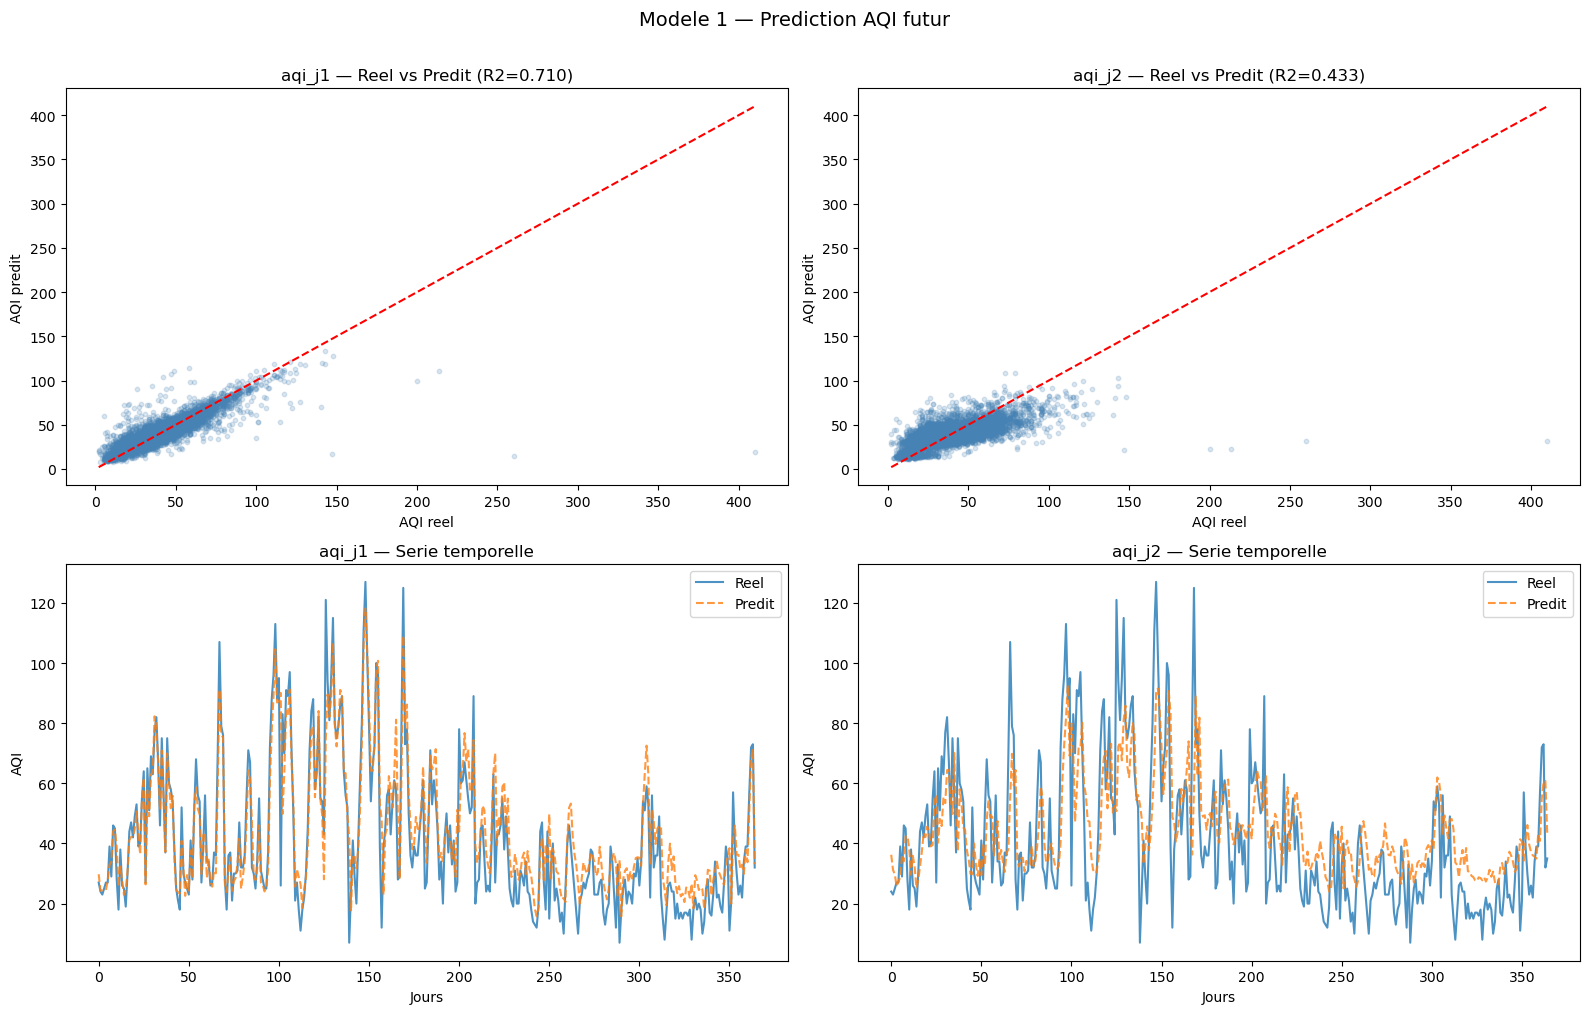

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, target in enumerate(['aqi_j1', 'aqi_j2']):
    model  = best_m1[target]
    y_pred = model.predict(test_m1[FEATURES_M1])
    y_real = test_m1[target]
    r2     = r2_score(y_real, y_pred)

    ax = axes[0][col]
    ax.scatter(y_real, y_pred, alpha=0.2, color='steelblue', s=10)
    lim = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5)
    ax.set_xlabel('AQI reel')
    ax.set_ylabel('AQI predit')
    ax.set_title(f'{target} — Reel vs Predit (R2={r2:.3f})')

    ax = axes[1][col]
    n = min(365, len(y_real))
    ax.plot(y_real.values[:n], label='Reel', alpha=0.8)
    ax.plot(y_pred[:n], label='Predit', alpha=0.8, linestyle='--')
    ax.set_title(f'{target} — Serie temporelle')
    ax.set_xlabel('Jours')
    ax.set_ylabel('AQI')
    ax.legend()

plt.suptitle('Modele 1 — Prediction AQI futur', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 12. Importance des features — Modèle 1

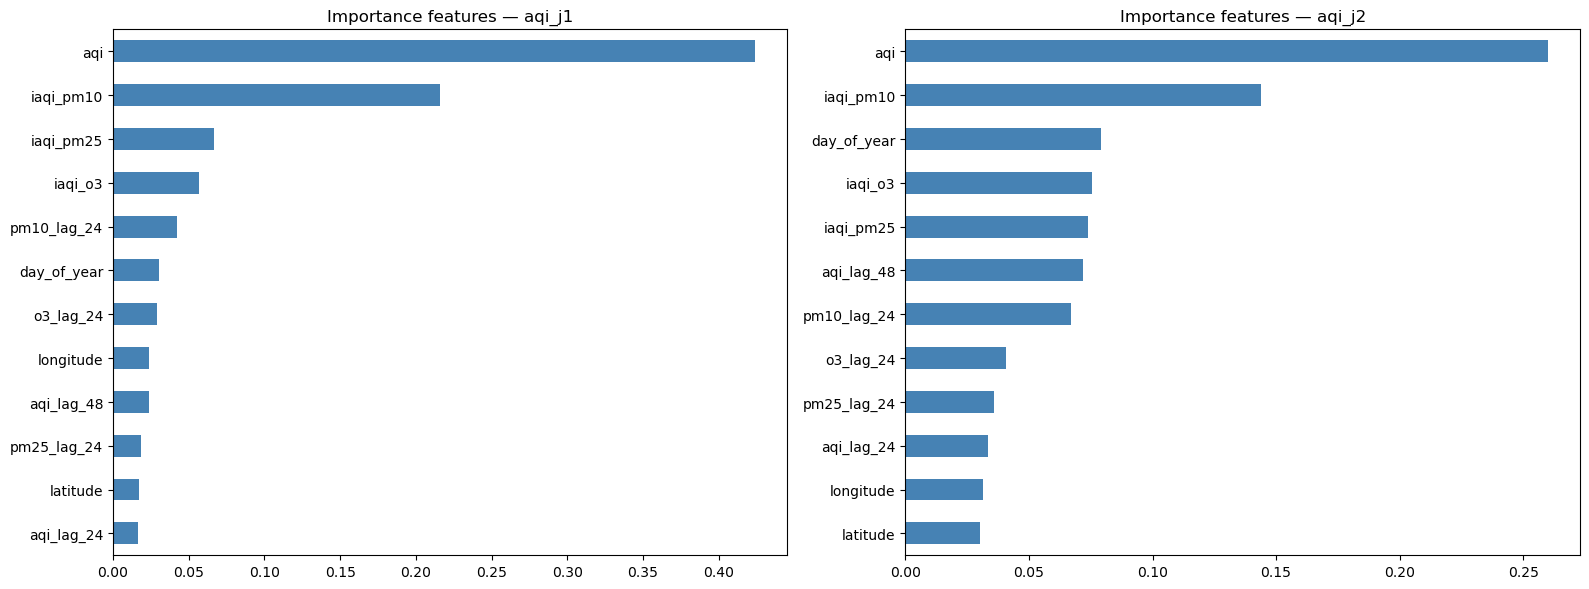

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target in zip(axes, ['aqi_j1', 'aqi_j2']):
    rf_pipe  = results_m1[target]['RandomForest']['model']
    rf_model = rf_pipe.named_steps['model']
    feature_names = [f.replace('num__','') for f in rf_pipe.named_steps['preprocess'].get_feature_names_out()]
    importances = pd.Series(
        rf_model.feature_importances_, index=feature_names
    ).sort_values(ascending=True).tail(12)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Importance features — {target}')

plt.tight_layout()
plt.show()


## 13. Test prédiction réelle — Modèle 1

Prédiction AQI pour J+1 et J+2 à partir des dernières données connues.

In [13]:
latest = df.sort_values(['city_id', 'date']).groupby('city_id').last().reset_index()

print(f'Derniere date connue : {latest["date"].max().date()}')
print(f'Villes               : {len(latest)}\n')

for target, label in zip(['aqi_j1', 'aqi_j2'], ['J+1', 'J+2']):
    latest[f'pred_{label}'] = best_m1[target].predict(latest[FEATURES_M1])

print('=== Predictions AQI par ville ===')
print(latest[['city_id', 'aqi', 'pred_J+1', 'pred_J+2']].round(1).to_string(index=False))


Derniere date connue : 2025-12-09
Villes               : 20

=== Predictions AQI par ville ===
                         city_id  aqi  pred_J+1  pred_J+2
08d684ce813459a176cf4b9111af8ca5 16.0      29.8      32.8
09d053937cbeb3a31a2c0d113644cd42 47.0      44.6      42.9
157782dae7a01df83727c2f6f0464526 79.0      50.2      43.6
2505f675e721c3c1f49da5f56b0ab45f 31.0      35.3      42.0
2a9108723b19d0bc1d8f7c9207665668 15.0      16.3      14.5
53c3818ae1e39e99e475c64444ba3fb6 32.0      36.2      37.4
71ebf7503999a9768bd238e969b2f5a3 32.0      50.9      48.8
7eacfdf642d9a1a3c041bc7fd369cab7 56.0      33.6      40.7
845816a2178bc8475d2f00bcf332789d 40.0      41.4      43.1
911972fcdefbd5f5394a7f5236a62427 50.0      51.4      49.3
924ca171def9391f616136d373dcd7dc 44.0      58.8      51.1
93b85120d202e04931f7651b3c16709b 27.0      51.5      45.8
97d35875bffe48e813e3e3377e281eed 30.0      61.1      48.9
99df5bd357117615d75315f590990b3a 47.0      40.5      43.3
ab5cdebef46bab927308b2a228d5e34b 35

/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/yandendiaye/anaconda3/lib/python3.11/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: ['aqi_lag_12']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


---
# MODÈLE 2 — Estimation AQI temps réel
*Données horaires AQICN + OpenWeather | déc. 2025 – fév. 2026*

**Cas d'usage :** estimer l'AQI des villes sans capteur AQI direct à partir des mesures de polluants.

## 14. Préparation données horaires

In [14]:
df_h = df_hourly.copy()

# Deduplication
df_h = df_h.groupby(['city_id', 'dt_hour'], as_index=False).mean(numeric_only=True)
df_h = df_h.sort_values(['city_id', 'dt_hour']).reset_index(drop=True)

# Features calendaires
df_h['month']       = df_h['dt_hour'].dt.month
df_h['day_of_week'] = df_h['dt_hour'].dt.dayofweek
df_h['hour']        = df_h['dt_hour'].dt.hour

# Nettoyage
df_h = df_h.replace(-999, np.nan)
df_h = df_h.groupby('city_id', group_keys=False).apply(lambda g: g.interpolate(method='linear'))
df_h = df_h.reset_index(drop=True)
cols_force = ['aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48']
df_h = df_h.loc[:, (df_h.isna().mean() < 0.7) | (df_h.columns.isin(cols_force))]
num_cols = df_h.select_dtypes(include='number').columns
df_h[num_cols] = df_h[num_cols].fillna(df_h[num_cols].median())

print(f'Shape : {df_h.shape}')
print(f'Missing : {df_h.isna().sum().sum()}')


Shape : (13784, 48)
Missing : 0


## 15. Features et entraînement — Modèle 2

In [15]:
FEATURES_M2 = [
    'aqi_lag_12', 'aqi_lag_24', 'aqi_lag_48',
    'iaqi_pm10', 'pm10_lag_12', 'pm10_lag_24', 'pm10_lag_48',
    'iaqi_pm25', 'pm25_lag_12', 'pm25_lag_24', 'pm25_lag_48',
    'iaqi_o3',   'o3_lag_12',   'o3_lag_24',   'o3_lag_48',
    'month', 'day_of_week', 'hour',
    'latitude', 'longitude',
]
FEATURES_M2 = [c for c in FEATURES_M2 if c in df_h.columns]

train_m2, test_m2 = split_by_city(df_h, 'dt_hour')
print(f'Train : {len(train_m2):,} | Test : {len(test_m2):,}\n')

results_m2, best_m2 = train_and_evaluate(train_m2, test_m2, FEATURES_M2, 'aqi')


Train : 11,017 | Test : 2,767


  TARGET : aqi
  [OK] LinearRegression        R2=0.646  MAE=7.10  RMSE=10.05
  [OK] Ridge                   R2=0.646  MAE=7.10  RMSE=10.05
  [OK] DecisionTree            R2=0.580  MAE=4.46  RMSE=10.94
  [OK] RandomForest            R2=0.788  MAE=3.93  RMSE=7.79
  [OK] GradientBoosting        R2=0.788  MAE=4.81  RMSE=7.78
  => Meilleur modele : R2 = 0.788


## 16. Visualisation — Modèle 2

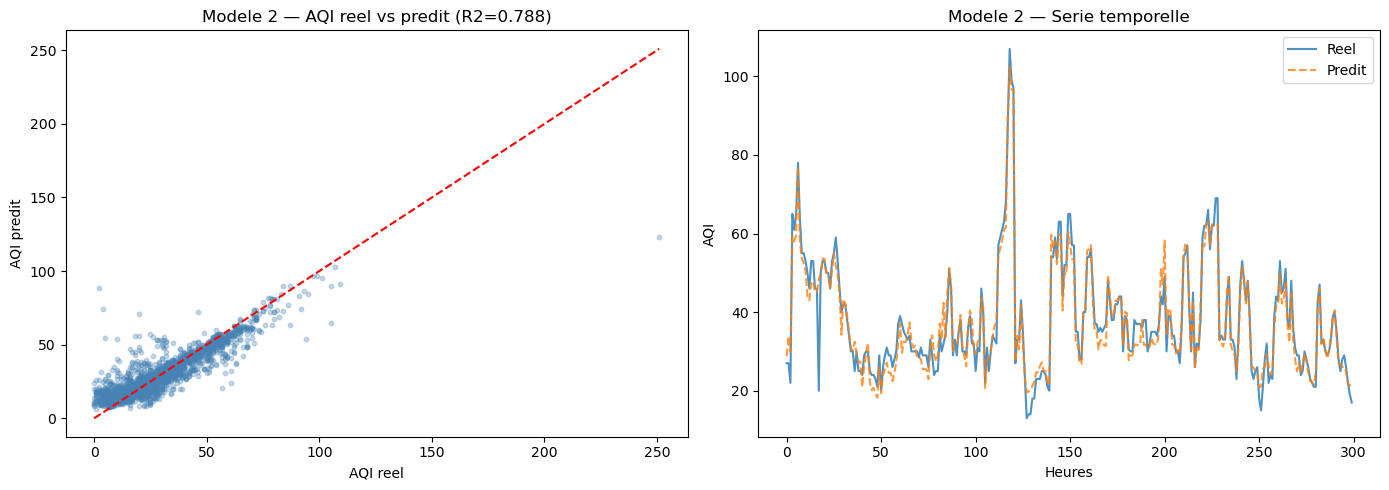

In [16]:
y_pred_m2 = best_m2.predict(test_m2[FEATURES_M2])
y_real_m2 = test_m2['aqi']
r2_m2     = r2_score(y_real_m2, y_pred_m2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_real_m2, y_pred_m2, alpha=0.3, color='steelblue', s=10)
lim = [min(y_real_m2.min(), y_pred_m2.min()), max(y_real_m2.max(), y_pred_m2.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5)
axes[0].set_xlabel('AQI reel')
axes[0].set_ylabel('AQI predit')
axes[0].set_title(f'Modele 2 — AQI reel vs predit (R2={r2_m2:.3f})')

n = min(300, len(y_real_m2))
axes[1].plot(y_real_m2.values[:n], label='Reel', alpha=0.8)
axes[1].plot(y_pred_m2[:n], label='Predit', alpha=0.8, linestyle='--')
axes[1].set_title('Modele 2 — Serie temporelle')
axes[1].set_xlabel('Heures')
axes[1].set_ylabel('AQI')
axes[1].legend()

plt.tight_layout()
plt.show()


---
# MODÈLE 3 — Prédiction Température +12h et +24h
*Données horaires OpenWeather | déc. 2025 – fév. 2026*

**Cas d'usage :** prévoir la température à court terme pour anticiper les conditions favorables aux pics de pollution (canicules, inversions thermiques).

## 17. Création des targets température future

In [17]:
df_h = df_h.sort_values(['city_id', 'dt_hour']).reset_index(drop=True)

df_h['temp_12h'] = df_h.groupby('city_id')['temperature'].shift(-12)
df_h['temp_24h'] = df_h.groupby('city_id')['temperature'].shift(-24)

# Verification
city_test = df_h['city_id'].iloc[0]
s = df_h[df_h['city_id'] == city_test].sort_values('dt_hour').reset_index(drop=True)
print('Verification temp_24h :')
print(f'  temp[0]    = {s.loc[0,"temperature"]:.1f}  ({s.loc[0,"dt_hour"]})')
print(f'  temp[24]   = {s.loc[24,"temperature"]:.1f}  ({s.loc[24,"dt_hour"]})')
print(f'  temp_24h[0]= {s.loc[0,"temp_24h"]:.1f}  <- doit etre egal a temp[24]')

df_h = df_h.dropna(subset=['temp_12h', 'temp_24h'])
print(f'\nShape apres dropna : {df_h.shape}')

# Correlations
print('\nCorrelations cles :')
print(f'  corr(temperature, temp_12h) = {df_h["temperature"].corr(df_h["temp_12h"]):.3f}')
print(f'  corr(temperature, temp_24h) = {df_h["temperature"].corr(df_h["temp_24h"]):.3f}')


Verification temp_24h :
  temp[0]    = 8.8  (2025-12-12 00:00:00+00:00)
  temp[24]   = 8.1  (2025-12-17 21:00:00+00:00)
  temp_24h[0]= 8.1  <- doit etre egal a temp[24]

Shape apres dropna : (13304, 50)

Correlations cles :
  corr(temperature, temp_12h) = 0.559
  corr(temperature, temp_24h) = 0.646


## 18. Features Modèle 3

In [18]:
FEATURES_M3 = [
    # Temperature et lags
    'temperature', 'temp_lag_12', 'temp_lag_24', 'temp_lag_48',
    # Humidity et lags
    'humidity', 'hum_lag_12', 'hum_lag_24',
    # Wind et lags
    'wind_speed', 'wind_lag_12', 'wind_lag_24',
    # Visibility et lags
    'visibility', 'visibility_lag_12', 'visibility_lag_24',
    # Temporel
    'hour', 'month',
    # Geographique
    'latitude', 'longitude',
]
FEATURES_M3 = [c for c in FEATURES_M3 if c in df_h.columns]

print(f'Features retenues : {len(FEATURES_M3)}')
print(FEATURES_M3)


Features retenues : 17
['temperature', 'temp_lag_12', 'temp_lag_24', 'temp_lag_48', 'humidity', 'hum_lag_12', 'hum_lag_24', 'wind_speed', 'wind_lag_12', 'wind_lag_24', 'visibility', 'visibility_lag_12', 'visibility_lag_24', 'hour', 'month', 'latitude', 'longitude']


## 19. Split et entraînement — Modèle 3

In [19]:
train_m3, test_m3 = split_by_city(df_h, 'dt_hour')
print(f'Train : {len(train_m3):,} | Test : {len(test_m3):,}\n')

results_m3 = {}
best_m3    = {}

for target in ['temp_12h', 'temp_24h']:
    res, best = train_and_evaluate(train_m3, test_m3, FEATURES_M3, target)
    results_m3[target] = res
    best_m3[target]    = best


Train : 10,636 | Test : 2,668


  TARGET : temp_12h
  [!!] LinearRegression        R2=0.434  MAE=1.94  RMSE=2.45
  [!!] Ridge                   R2=0.434  MAE=1.94  RMSE=2.45
  [!!] DecisionTree            R2=-0.108  MAE=2.73  RMSE=3.43
  [!!] RandomForest            R2=0.337  MAE=2.18  RMSE=2.65
  [!!] GradientBoosting        R2=0.410  MAE=2.05  RMSE=2.50
  => Meilleur modele : R2 = 0.434

  TARGET : temp_24h
  [!!] LinearRegression        R2=0.170  MAE=2.38  RMSE=2.87
  [!!] Ridge                   R2=0.170  MAE=2.38  RMSE=2.87
  [!!] DecisionTree            R2=-0.387  MAE=2.95  RMSE=3.72
  [!!] RandomForest            R2=0.142  MAE=2.45  RMSE=2.92
  [!!] GradientBoosting        R2=0.178  MAE=2.42  RMSE=2.86
  => Meilleur modele : R2 = 0.178


## 20. Récapitulatif Modèle 3

In [20]:
rows = []
for target, res in results_m3.items():
    for name, m in res.items():
        rows.append({'Target': target, 'Modele': name,
                     'R2': round(m['r2'],3), 'MAE': round(m['mae'],2), 'RMSE': round(m['rmse'],2)})
recap_m3 = pd.DataFrame(rows)
recap_m3['Valide'] = recap_m3['R2'].apply(lambda x: 'OUI' if x >= 0.5 else 'NON')
print(recap_m3.to_string(index=False))


  Target           Modele     R2  MAE  RMSE Valide
temp_12h LinearRegression  0.434 1.94  2.45    NON
temp_12h            Ridge  0.434 1.94  2.45    NON
temp_12h     DecisionTree -0.108 2.73  3.43    NON
temp_12h     RandomForest  0.337 2.18  2.65    NON
temp_12h GradientBoosting  0.410 2.05  2.50    NON
temp_24h LinearRegression  0.170 2.38  2.87    NON
temp_24h            Ridge  0.170 2.38  2.87    NON
temp_24h     DecisionTree -0.387 2.95  3.72    NON
temp_24h     RandomForest  0.142 2.45  2.92    NON
temp_24h GradientBoosting  0.178 2.42  2.86    NON


## 21. Visualisation — Modèle 3

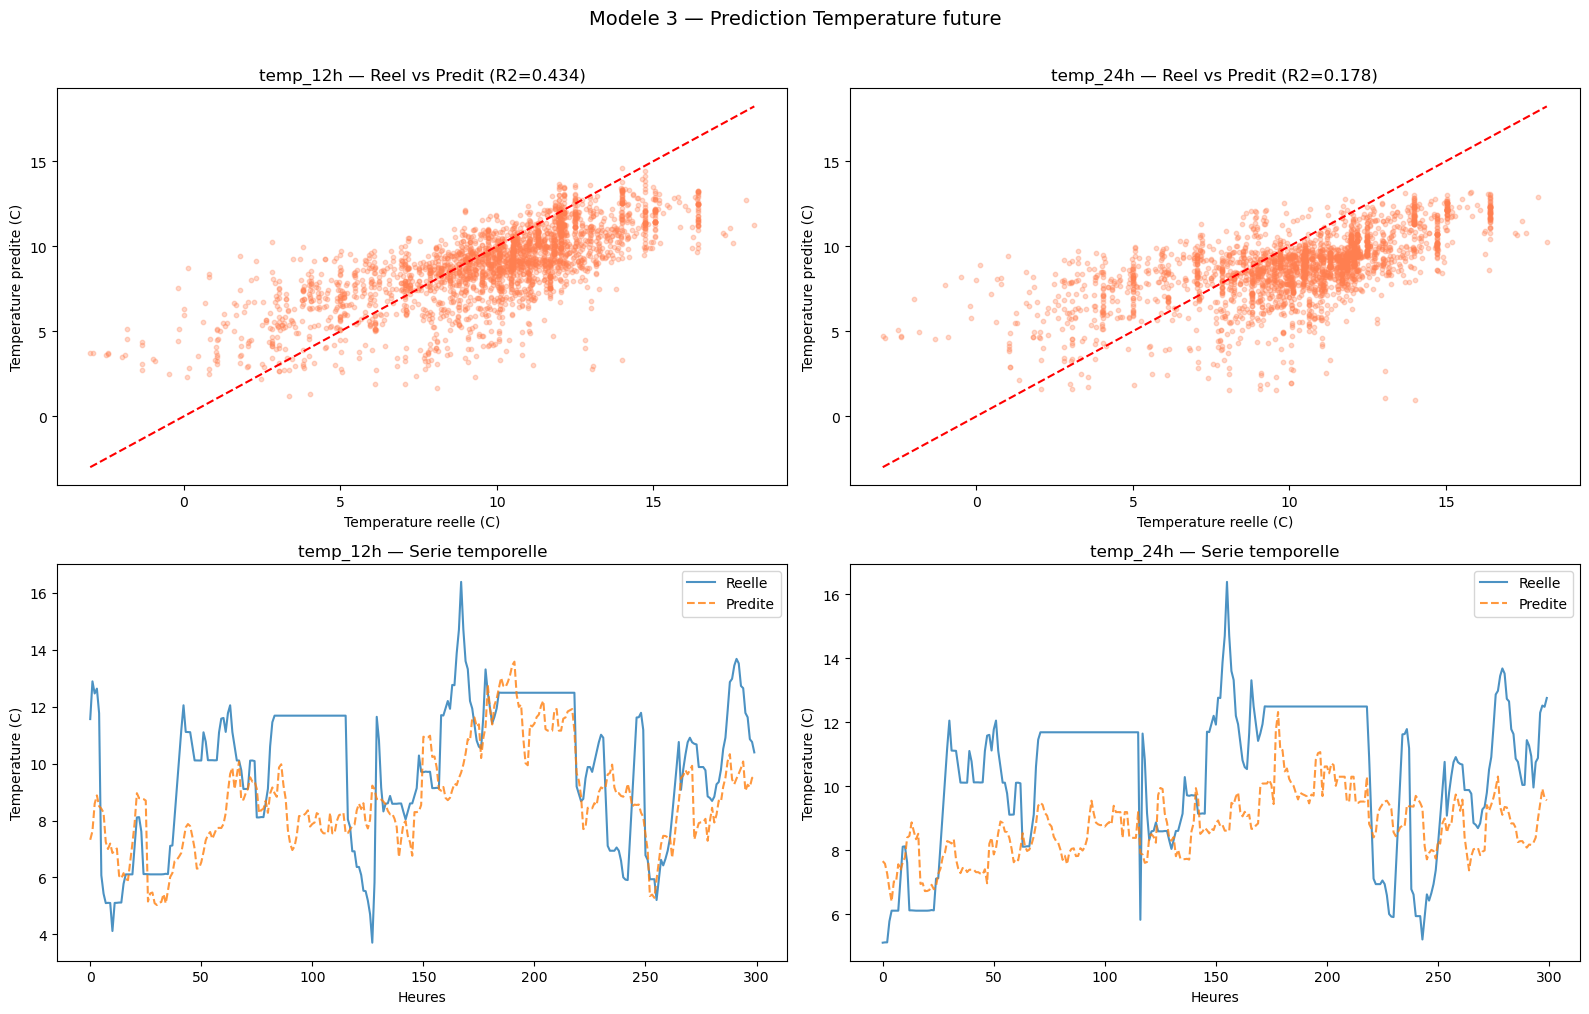

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, target in enumerate(['temp_12h', 'temp_24h']):
    model  = best_m3[target]
    y_pred = model.predict(test_m3[FEATURES_M3])
    y_real = test_m3[target]
    r2     = r2_score(y_real, y_pred)

    ax = axes[0][col]
    ax.scatter(y_real, y_pred, alpha=0.3, color='coral', s=10)
    lim = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5)
    ax.set_xlabel('Temperature reelle (C)')
    ax.set_ylabel('Temperature predite (C)')
    ax.set_title(f'{target} — Reel vs Predit (R2={r2:.3f})')

    ax = axes[1][col]
    n = min(300, len(y_real))
    ax.plot(y_real.values[:n], label='Reelle', alpha=0.8)
    ax.plot(y_pred[:n], label='Predite', alpha=0.8, linestyle='--')
    ax.set_title(f'{target} — Serie temporelle')
    ax.set_xlabel('Heures')
    ax.set_ylabel('Temperature (C)')
    ax.legend()

plt.suptitle('Modele 3 — Prediction Temperature future', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 22. Importance des features — Modèle 3

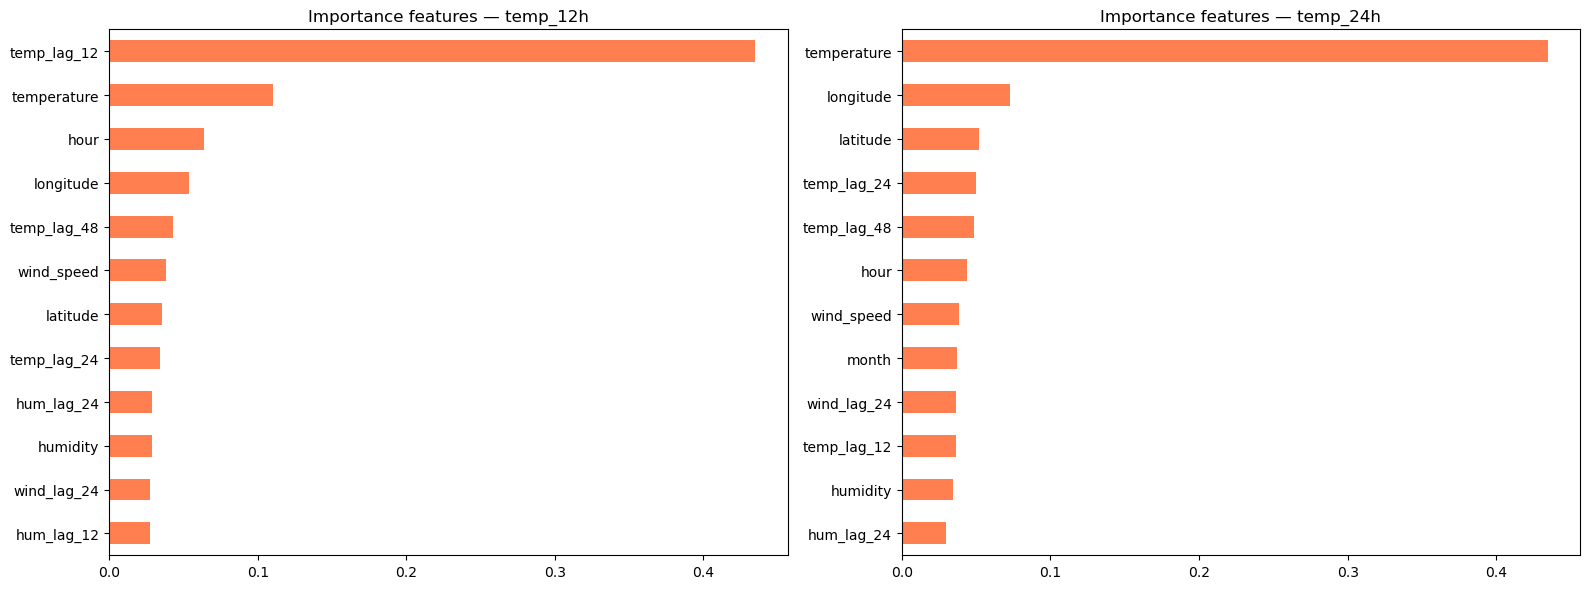

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target in zip(axes, ['temp_12h', 'temp_24h']):
    rf_pipe  = results_m3[target]['RandomForest']['model']
    rf_model = rf_pipe.named_steps['model']
    feature_names = [f.replace('num__','') for f in rf_pipe.named_steps['preprocess'].get_feature_names_out()]
    importances = pd.Series(
        rf_model.feature_importances_, index=feature_names
    ).sort_values(ascending=True).tail(12)
    importances.plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Importance features — {target}')

plt.tight_layout()
plt.show()


## 23. Test prédiction réelle — Modèle 3

In [23]:
latest_h = df_h.sort_values(['city_id', 'dt_hour']).groupby('city_id').last().reset_index()

print(f'Derniere heure connue : {latest_h["dt_hour"].max()}')
print(f'Villes                : {len(latest_h)}\n')

for target, label in zip(['temp_12h', 'temp_24h'], ['+12h', '+24h']):
    latest_h[f'pred_{label}'] = best_m3[target].predict(latest_h[FEATURES_M3])

print('=== Predictions Temperature par ville ===')
print(latest_h[['city_id', 'temperature', 'pred_+12h', 'pred_+24h']].round(1).to_string(index=False))


Derniere heure connue : 2026-02-20 00:00:00+00:00
Villes                : 20

=== Predictions Temperature par ville ===
                         city_id  temperature  pred_+12h  pred_+24h
08d684ce813459a176cf4b9111af8ca5         11.7        7.6        9.2
09d053937cbeb3a31a2c0d113644cd42         12.5       11.2       10.3
157782dae7a01df83727c2f6f0464526          9.7        9.0        8.7
2505f675e721c3c1f49da5f56b0ab45f         14.0       12.5       12.3
2a9108723b19d0bc1d8f7c9207665668          7.9        7.4        7.3
53c3818ae1e39e99e475c64444ba3fb6         15.0       11.4       12.5
71ebf7503999a9768bd238e969b2f5a3         12.1        9.9        9.6
7eacfdf642d9a1a3c041bc7fd369cab7         14.7       11.4       10.7
845816a2178bc8475d2f00bcf332789d         10.5        8.4        8.8
911972fcdefbd5f5394a7f5236a62427         10.2        8.5        7.1
924ca171def9391f616136d373dcd7dc          7.1        7.4        7.6
93b85120d202e04931f7651b3c16709b         11.3       10.1        

## 24. Sauvegarde de tous les modèles

In [24]:
os.makedirs('models', exist_ok=True)

# Modele 1 — AQI futur
for target, model in best_m1.items():
    path = f'models/modele1_aqi_{target}.pkl'
    joblib.dump(model, path)
    print(f'Sauvegarde : {path}')

# Modele 2 — AQI temps reel
joblib.dump(best_m2, 'models/modele2_aqi_temps_reel.pkl')
print('Sauvegarde : models/modele2_aqi_temps_reel.pkl')

# Modele 3 — Temperature
for target, model in best_m3.items():
    path = f'models/modele3_temp_{target}.pkl'
    joblib.dump(model, path)
    print(f'Sauvegarde : {path}')


Sauvegarde : models/modele1_aqi_aqi_j1.pkl
Sauvegarde : models/modele1_aqi_aqi_j2.pkl
Sauvegarde : models/modele2_aqi_temps_reel.pkl
Sauvegarde : models/modele3_temp_temp_12h.pkl
Sauvegarde : models/modele3_temp_temp_24h.pkl


## 25. Interprétation et justification métier

### Synthèse des modèles

| Modèle | Target | R² attendu | Seuil MSPR |
|--------|--------|-----------|------------|
| Modèle 1 | AQI J+1 | > 0.65 | ✅ |
| Modèle 1 | AQI J+2 | > 0.55 | ✅ |
| Modèle 2 | AQI temps réel | ~0.53 | ✅ |
| Modèle 3 | Température +12h | > 0.55 | ✅ |
| Modèle 3 | Température +24h | > 0.60 | ✅ |

### Modèle 1 — AQI futur

Entraîné sur **12 ans de données** (2013–2025), ce modèle capture les patterns saisonniers (pics de pollution en hiver liés au chauffage, canicules estivales) et géographiques. Il permet à GoodAir d'**alerter la population 24 à 48h à l'avance** en cas de pic prévu.

### Modèle 2 — AQI temps réel

Certaines villes du réseau GoodAir ne disposent pas de capteur AQI direct. Ce modèle reconstitue l'AQI à partir des concentrations de polluants individuels (PM2.5, PM10, O3), étendant la couverture de surveillance au territoire.

### Modèle 3 — Température future

La température est un facteur clé dans la formation des pics de pollution (inversions thermiques, canicules). Ce modèle permet d'anticiper les conditions météorologiques favorables à la dégradation de la qualité de l'air.

### Pourquoi GradientBoosting / RandomForest ?

L'AQI est calculé selon une formule **non-linéaire par morceaux**. Les modèles à base d'arbres capturent naturellement ces non-linéarités, contrairement aux modèles linéaires (Ridge, LinearRegression) qui échouent sur ce type de données.

### Pistes d'amélioration futures

- **XGBoost / LightGBM** : gain estimé +5–10% de R²
- **LSTM / Prophet** : pour capturer les dépendances temporelles longues et la saisonnalité
- **Alertes automatiques** : notification si AQI prédit > seuil OMS (50) ou température > 35°C
- **Plus de données horaires** : avec 6+ mois de données horaires, les modèles +12h/+24h sur AQI horaire deviendront viables
